# Intra-session Conversion Propensity
## Portfolio Data Scientist Case Study

**Candidate:** António Navalhas  
**Objective:** Estimate the probability that an active e-commerce session will result in a transaction, using only information available at the scoring moment.  
**Delivery:** Reproducible prototype, evaluation, interpretation, activation proposal and production considerations.

> **Portfolio version:** Company references and data-source identifiers have been anonymized.


## Executive summary

This notebook treats conversion propensity as a **dynamic, supervised classification problem**. A score should be updated as the visitor progresses through the session rather than calculated once with information that may not yet exist.

Two practical checkpoints are prototyped:

1. **T1 — Landing-page model:** scores every session immediately after the first page.
2. **T3 — Third-page model:** refreshes the score for sessions that have reached a third page.

The dataset is highly imbalanced and contains an important structural pattern: every recorded conversion occurs in a row with a third page. A naïve model using page availability across the full population would therefore learn session depth rather than genuine purchase intent. To avoid this proxy leakage, T1 never uses future page information and T3 is trained only within the population that has already reached the third page.

The final solution is evaluated primarily with **PR-AUC, lift, recall at the top-ranked fraction and probability calibration**, because accuracy is misleading when conversion is rare. The notebook ends with activation ideas for on-site personalisation and marketing audiences, together with an experimentation plan to measure incremental value.


## 1. Business framing

### What is being predicted?

For an active session, estimate:

> **P(transaction later in the same session | information observed up to the scoring checkpoint)**

The target is `transaction`, where 1 indicates a completed transaction and 0 indicates no transaction.

### Why checkpoints matter

A valid intra-session model must respect the order in which information becomes available:

| Checkpoint | Scoring moment | Available information |
|---|---|---|
| T1 | After landing page | Visitor, channel, device, geography, time, session number and landing page |
| T2 | After second page | T1 information plus second page and time to second page |
| T3 | After third page | T2 information plus third page and navigation timing |

This prototype implements T1 and T3. T2 follows the same design and can be added without changing the architecture.

### Supervised vs. unsupervised learning

This is a **supervised-learning** problem because historical sessions have a known outcome. Unsupervised methods such as clustering could complement the solution by discovering behavioural segments, but they are not the primary method for estimating conversion probability.


In [1]:
# Core libraries
from pathlib import Path
import warnings
import os

# Keep numerical libraries single-threaded for reproducible notebook execution.
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    brier_score_loss,
    log_loss,
)
from sklearn.calibration import calibration_curve

from lightgbm import LGBMClassifier, early_stopping, log_evaluation

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
RANDOM_STATE = 42


### Reproducibility

The notebook uses a fixed random seed and a temporal train/validation/test split. Required packages are `pandas`, `numpy`, `matplotlib`, `scikit-learn` and `lightgbm`.


In [2]:
# Locate the supplied CSV whether the notebook is run in the submission folder or /mnt/data.
candidates = [
    Path("ecommerce_sessions.csv"),
    Path("ecommerce_sessions.csv"),
    Path("/mnt/data/ecommerce_sessions.csv"),
]

DATA_PATH = next((p for p in candidates if p.exists()), None)
if DATA_PATH is None:
    matches = list(Path.cwd().glob("ecommerce_sessions*.csv"))
    if not matches:
        raise FileNotFoundError(
            "CSV not found. Place the anonymized e-commerce sessions CSV in the same folder as this notebook."
        )
    DATA_PATH = matches[0]

raw = pd.read_csv(
    DATA_PATH,
    dtype={"userId": "string", "sessId": "string"},
    low_memory=False,
)
raw["visit_dt"] = pd.to_datetime(raw["visitStartTime"], unit="s", utc=True)
raw = raw.sort_values("visit_dt").reset_index(drop=True)

print(f"Loaded: {DATA_PATH}")
print(f"Shape: {raw.shape[0]:,} rows × {raw.shape[1]:,} columns")
display(raw.head(3))


Loaded: ecommerce_sessions.csv
Shape: 71,796 rows × 21 columns


,userId,sessId,newVisitor,visitStartTime,weekday,hour,medium,source,device,browser,country,region,transaction,sessionNumber,landingPage,hitTimeLP,secondPage,hitsTimeSecondPage,thirdPage,hitsTimeThirdPage,visit_dt
0,8809483339747744935,88094833397477449351498892405,1,1498892405,7,7,organic,search-engine,mobile,Chrome,United States,Pennsylvania,0,1,/home,0,/home,"84,199.0000",/home,"89,055.0000",2017-07-01 07:00:05+00:00
1,7327488272095893888,73274882720958938881498892513,1,1498892513,7,7,organic,search-engine,mobile,Chrome,Philippines,Metro Manila,0,1,/storefront/apparel/mens/mens+t+shirts,0,NaN,NaN,NaN,NaN,2017-07-01 07:01:53+00:00
2,643710157054081077,6437101570540810771498892545,1,1498892545,7,7,organic,search-engine,desktop,Chrome,United States,California,0,1,/home,0,/home,"6,526.0000",/home,"24,859.0000",2017-07-01 07:02:25+00:00


## 2. Data understanding and quality checks

The case brief states that each row contains session-level information. Before modelling, the dataset is checked for class balance, missing behavioural events, date coverage, identifier consistency and event-order anomalies.


In [3]:
quality_summary = pd.DataFrame(
    {
        "Metric": [
            "Rows",
            "Unique users",
            "Unique session IDs",
            "Transactions",
            "Conversion rate",
            "Rows without second page",
            "Rows without third page",
            "Repeated userId + sessId combinations",
            "Exact duplicate rows",
            "Third-page time earlier than second-page time",
            "Observed weekday range",
            "Data start",
            "Data end",
        ],
        "Value": [
            f"{len(raw):,}",
            f"{raw['userId'].nunique():,}",
            f"{raw['sessId'].nunique():,}",
            f"{int(raw['transaction'].sum()):,}",
            f"{raw['transaction'].mean():.2%}",
            f"{raw['secondPage'].isna().mean():.2%}",
            f"{raw['thirdPage'].isna().mean():.2%}",
            f"{raw.duplicated(['userId', 'sessId']).sum():,}",
            f"{raw.duplicated().sum():,}",
            f"{((raw['hitsTimeThirdPage'] < raw['hitsTimeSecondPage']) & raw['hitsTimeThirdPage'].notna() & raw['hitsTimeSecondPage'].notna()).sum():,}",
            f"{raw['weekday'].min()} to {raw['weekday'].max()}",
            raw["visit_dt"].min().strftime("%Y-%m-%d %H:%M UTC"),
            raw["visit_dt"].max().strftime("%Y-%m-%d %H:%M UTC"),
        ],
    }
)
display(quality_summary)


,Metric,Value
0,Rows,"71,796"
1,Unique users,"58,569"
2,Unique session IDs,"71,692"
3,Transactions,"1,031"
4,Conversion rate,1.44%
5,Rows without second page,50.88%
6,Rows without third page,64.86%
7,Repeated userId + sessId combinations,104
8,Exact duplicate rows,0
9,Third-page time earlier than second-page time,32


### Quality observations and modelling decisions

- The positive class is rare, so accuracy is not an appropriate primary metric.
- The documentation describes `weekday` as 0–6, while the data contains 1–7. The observed encoding is used consistently.
- A small number of `userId + sessId` combinations occurs more than once, sometimes with different timestamps or outcomes. No exact duplicate rows exist. These records are retained because their semantics cannot be resolved safely without source-system clarification; a production pipeline should define the canonical session key.
- A small number of third-page timestamps precedes the second-page timestamp. Negative intervals are clipped to zero and the issue is reported rather than silently ignored.
- The data spans approximately one month, which limits seasonality and drift conclusions.


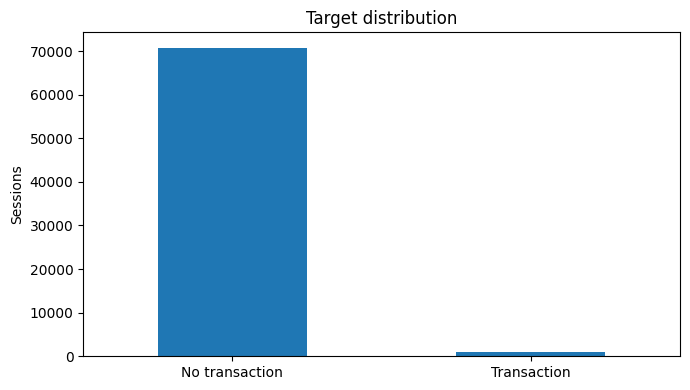

A classifier that always predicts 'no transaction' would achieve 98.56% accuracy while identifying no buyers.


In [4]:
# Target distribution
class_counts = raw["transaction"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(7, 4))
class_counts.rename(index={0: "No transaction", 1: "Transaction"}).plot(kind="bar", ax=ax)
ax.set_title("Target distribution")
ax.set_xlabel("")
ax.set_ylabel("Sessions")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

print(
    f"A classifier that always predicts 'no transaction' would achieve "
    f"{(1 - raw['transaction'].mean()):.2%} accuracy while identifying no buyers."
)


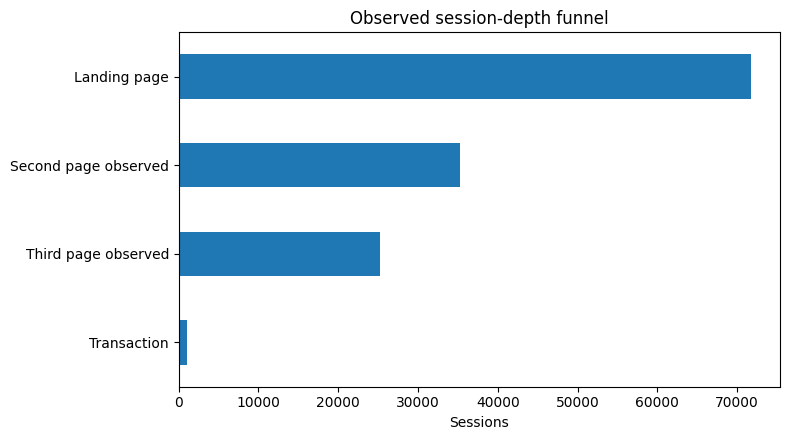

transaction,No transaction,Transaction
thirdPage,,
No third page,46569,0
Third page observed,24196,1031


Share of transactions with a recorded third page: 100.00%


In [5]:
# Behavioural funnel: the rows available at each observation depth.
funnel = pd.Series(
    {
        "Landing page": len(raw),
        "Second page observed": raw["secondPage"].notna().sum(),
        "Third page observed": raw["thirdPage"].notna().sum(),
        "Transaction": raw["transaction"].sum(),
    }
)

fig, ax = plt.subplots(figsize=(8, 4.5))
funnel.sort_values().plot(kind="barh", ax=ax)
ax.set_title("Observed session-depth funnel")
ax.set_xlabel("Sessions")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

page_presence = pd.crosstab(
    raw["thirdPage"].notna().map({False: "No third page", True: "Third page observed"}),
    raw["transaction"],
).rename(columns={0: "No transaction", 1: "Transaction"})
display(page_presence)

transactions_with_third = raw.loc[raw["transaction"].eq(1), "thirdPage"].notna().mean()
print(f"Share of transactions with a recorded third page: {transactions_with_third:.2%}")


### Critical leakage/proxy risk

Every recorded transaction has a third page. If the full dataset were modelled with indicators such as “third page exists”, the classifier could obtain strong apparent performance by learning **session depth**, not purchase intent. That feature is unavailable at T1 and is also almost a deterministic proxy for the label in this sample.

The prototype therefore follows two rules:

1. **T1 never uses second- or third-page information.**
2. **T3 is trained only among sessions where the third page is already observed.**

There is still no transaction timestamp, so it cannot be proven that the third page preceded the purchase. This is retained as a material limitation for production validation.


**Conversion by `device`**

,sessions,transactions,conversion_rate
_category,,,
desktop,45580,926,0.0203
tablet,3109,13,0.0042
mobile,23107,92,0.0040


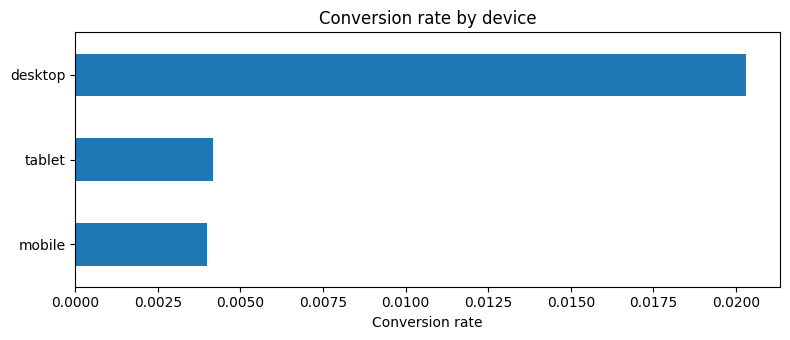

**Conversion by `medium`**

,sessions,transactions,conversion_rate
_category,,,
(none),19882,653,0.0328
cpm,687,19,0.0277
cpc,2009,45,0.0224
organic,36380,296,0.0081
affiliate,1788,4,0.0022
referral,11049,14,0.0013


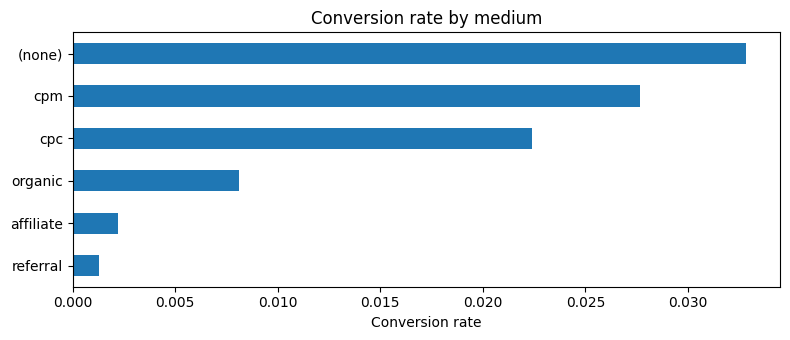

**Conversion by `newVisitor`**

,sessions,transactions,conversion_rate
_category,,,
0,17116,652,0.0381
1,54680,379,0.0069


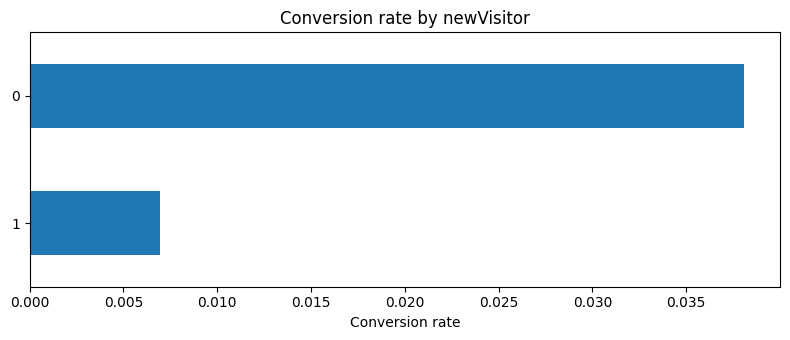

In [6]:
def conversion_table(data, column, min_sessions=100, top_n=12):
    # Return volume and conversion rate for sufficiently frequent categories.
    table = (
        data.assign(_category=data[column].fillna("Missing").astype(str))
        .groupby("_category", observed=True)["transaction"]
        .agg(sessions="size", transactions="sum", conversion_rate="mean")
        .query("sessions >= @min_sessions")
        .sort_values(["conversion_rate", "sessions"], ascending=False)
        .head(top_n)
    )
    return table

for feature, min_sessions in [("device", 100), ("medium", 100), ("newVisitor", 100)]:
    table = conversion_table(raw, feature, min_sessions=min_sessions)
    display(Markdown(f"**Conversion by `{feature}`**"))
    display(table)

    fig, ax = plt.subplots(figsize=(8, max(3.5, len(table) * 0.35)))
    table.sort_values("conversion_rate")["conversion_rate"].plot(kind="barh", ax=ax)
    ax.set_title(f"Conversion rate by {feature}")
    ax.set_xlabel("Conversion rate")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()


The exploratory rates above are **associations**, not causal effects. For example, returning visitors may convert more often because they already know the brand; that does not prove that changing a visitor's status would cause a conversion.


## 3. Feature engineering

The feature set is designed around information availability.

### Common context features

- New vs. returning visitor
- Session number
- Cyclical hour and weekday representation
- Medium and source
- Device and browser
- Country and region
- Landing-page category

### T3 behavioural features

- Second and third page
- Time to second page
- Time to third page
- Time between second and third page
- Simple intent flags for basket/cart, sign-in/account and quick-view pages

Raw identifiers (`userId`, `sessId`) and raw timestamps are excluded from the model to reduce memorisation and improve generalisation.


In [7]:
def add_engineered_features(data):
    out = data.copy()

    # Cyclical time representation.
    out["hour_sin"] = np.sin(2 * np.pi * out["hour"] / 24)
    out["hour_cos"] = np.cos(2 * np.pi * out["hour"] / 24)
    out["weekday_sin"] = np.sin(2 * np.pi * (out["weekday"] - 1) / 7)
    out["weekday_cos"] = np.cos(2 * np.pi * (out["weekday"] - 1) / 7)

    # Navigation timing in seconds. Negative intervals are clipped because they indicate source-data anomalies.
    out["time_to_second_s"] = out["hitsTimeSecondPage"] / 1_000
    out["time_to_third_s"] = out["hitsTimeThirdPage"] / 1_000
    out["second_to_third_s"] = (
        out["hitsTimeThirdPage"] - out["hitsTimeSecondPage"]
    ) / 1_000

    for col in ["time_to_second_s", "time_to_third_s", "second_to_third_s"]:
        out[f"log1p_{col}"] = np.log1p(out[col].clip(lower=0))

    # Lightweight page-intent flags; these are transparent and easy to operationalise.
    patterns = {
        "basket": r"basket|cart",
        "signin": r"signin|login|account",
        "quickview": r"quickview|quick-view",
    }
    for page_col in ["landingPage", "secondPage", "thirdPage"]:
        page_text = out[page_col].fillna("").astype(str)
        for label, pattern in patterns.items():
            out[f"{page_col}_{label}"] = page_text.str.contains(
                pattern, case=False, regex=True
            ).astype(int)

    return out

model_data = add_engineered_features(raw)

T1_NUMERIC = [
    "newVisitor", "sessionNumber", "hour_sin", "hour_cos",
    "weekday_sin", "weekday_cos",
]
T1_CATEGORICAL = [
    "medium", "source", "device", "browser", "country", "region", "landingPage",
]
T1_FEATURES = T1_NUMERIC + T1_CATEGORICAL

T3_NUMERIC = T1_NUMERIC + [
    "log1p_time_to_second_s", "log1p_time_to_third_s", "log1p_second_to_third_s",
    "landingPage_basket", "landingPage_signin", "landingPage_quickview",
    "secondPage_basket", "secondPage_signin", "secondPage_quickview",
    "thirdPage_basket", "thirdPage_signin", "thirdPage_quickview",
]
T3_CATEGORICAL = T1_CATEGORICAL + ["secondPage", "thirdPage"]
T3_FEATURES = T3_NUMERIC + T3_CATEGORICAL

print(f"T1 features: {len(T1_FEATURES)}")
print(f"T3 features: {len(T3_FEATURES)}")


T1 features: 13
T3 features: 27


## 4. Validation design

A random split can overstate performance when behaviour and traffic mix change over time. The dataset is sorted chronologically and divided into:

- **70% training:** fit model parameters.
- **15% validation:** early stopping and probability calibration.
- **15% test:** final untouched evaluation.

This approximates the real deployment pattern of learning from earlier traffic and scoring later traffic. A production evaluation should additionally use rolling backtests over several months and group-aware checks by user/session.


In [8]:
def temporal_split(data, train_fraction=0.70, validation_fraction=0.15):
    ordered = data.sort_values("visit_dt").reset_index(drop=True)
    train_end = int(len(ordered) * train_fraction)
    validation_end = int(len(ordered) * (train_fraction + validation_fraction))
    return (
        ordered.iloc[:train_end].copy(),
        ordered.iloc[train_end:validation_end].copy(),
        ordered.iloc[validation_end:].copy(),
    )


def split_summary(train, validation, test, label):
    rows = []
    for name, frame in [("Train", train), ("Validation", validation), ("Test", test)]:
        rows.append(
            {
                "checkpoint": label,
                "split": name,
                "rows": len(frame),
                "transactions": int(frame["transaction"].sum()),
                "conversion_rate": frame["transaction"].mean(),
                "start": frame["visit_dt"].min(),
                "end": frame["visit_dt"].max(),
            }
        )
    return pd.DataFrame(rows)

T1_train, T1_validation, T1_test = temporal_split(model_data)
T3_population = model_data.loc[model_data["thirdPage"].notna()].copy()
T3_train, T3_validation, T3_test = temporal_split(T3_population)

display(
    pd.concat(
        [
            split_summary(T1_train, T1_validation, T1_test, "T1 — landing"),
            split_summary(T3_train, T3_validation, T3_test, "T3 — third page"),
        ],
        ignore_index=True,
    )
)


,checkpoint,split,rows,transactions,conversion_rate,start,end
0,T1 — landing,Train,50257,698,0.0139,2017-07-01 07:00:05+00:00,2017-07-22 19:30:42+00:00
1,T1 — landing,Validation,10769,141,0.0131,2017-07-22 19:31:39+00:00,2017-07-27 09:22:16+00:00
2,T1 — landing,Test,10770,192,0.0178,2017-07-27 09:22:56+00:00,2017-08-01 06:59:43+00:00
3,T3 — third page,Train,17658,708,0.0401,2017-07-01 07:00:05+00:00,2017-07-23 13:13:44+00:00
4,T3 — third page,Validation,3784,142,0.0375,2017-07-23 13:13:48+00:00,2017-07-27 15:12:31+00:00
5,T3 — third page,Test,3785,181,0.0478,2017-07-27 15:14:29+00:00,2017-08-01 06:54:18+00:00


## 5. Evaluation metrics

Because only a small fraction of sessions converts:

- **PR-AUC** is the primary ranking metric.
- **ROC-AUC** is reported as a complementary discrimination measure.
- **Top-k precision, recall and lift** describe how concentrated conversions are among the highest-scored sessions.
- **Brier score and log loss** assess probability quality.
- **Calibration curves** compare predicted probabilities with observed conversion rates.

A fixed threshold of 0.50 is not used. The operational threshold should depend on intervention cost, expected margin and capacity.


In [9]:
def top_fraction_metrics(y_true, probabilities, fractions=(0.05, 0.10, 0.20)):
    y = np.asarray(y_true)
    p = np.asarray(probabilities)
    base_rate = y.mean()
    order = np.argsort(p)[::-1]
    rows = []

    for fraction in fractions:
        k = max(1, int(np.ceil(len(y) * fraction)))
        selected = y[order[:k]]
        precision = selected.mean()
        recall = selected.sum() / y.sum() if y.sum() else np.nan
        rows.append(
            {
                "top_fraction": fraction,
                "sessions_targeted": k,
                "precision": precision,
                "recall": recall,
                "lift": precision / base_rate if base_rate else np.nan,
            }
        )
    return pd.DataFrame(rows)


def probability_metrics(y_true, probabilities, model_name):
    return {
        "model": model_name,
        "test_sessions": len(y_true),
        "test_conversion_rate": np.mean(y_true),
        "ROC_AUC": roc_auc_score(y_true, probabilities),
        "PR_AUC": average_precision_score(y_true, probabilities),
        "Brier": brier_score_loss(y_true, probabilities),
        "LogLoss": log_loss(y_true, probabilities),
    }


def platt_calibrate(validation_probabilities, y_validation, test_probabilities):
    # Fit a logistic calibration layer on validation predictions only.
    eps = 1e-6

    def to_logit(p):
        clipped = np.clip(p, eps, 1 - eps)
        return np.log(clipped / (1 - clipped)).reshape(-1, 1)

    calibrator = LogisticRegression(random_state=RANDOM_STATE)
    calibrator.fit(to_logit(validation_probabilities), y_validation)
    calibrated_test = calibrator.predict_proba(to_logit(test_probabilities))[:, 1]
    return calibrator, calibrated_test


## 6. Baseline: interpretable logistic regression at T1

The baseline uses one-hot encoding for categorical variables, standardisation for numeric variables and class weighting. It establishes whether a more flexible model adds value beyond a transparent linear decision boundary.


In [10]:
# Prepare T1 baseline data.
X_train_baseline = T1_train[T1_FEATURES].copy()
X_test_baseline = T1_test[T1_FEATURES].copy()
y_train_T1 = T1_train["transaction"].astype(int)
y_validation_T1 = T1_validation["transaction"].astype(int)
y_test_T1 = T1_test["transaction"].astype(int)

for column in T1_CATEGORICAL:
    X_train_baseline[column] = X_train_baseline[column].fillna("__MISSING__").astype(str)
    X_test_baseline[column] = X_test_baseline[column].fillna("__MISSING__").astype(str)

baseline_preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), T1_NUMERIC),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="infrequent_if_exist",
                min_frequency=20,
                sparse_output=True,
            ),
            T1_CATEGORICAL,
        ),
    ]
)

baseline_model = Pipeline(
    steps=[
        ("preprocess", baseline_preprocessor),
        (
            "classifier",
            LogisticRegression(
                class_weight="balanced",
                max_iter=500,
                solver="saga",
                tol=1e-3,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

baseline_model.fit(X_train_baseline, y_train_T1)
baseline_test_probability = baseline_model.predict_proba(X_test_baseline)[:, 1]

baseline_result = probability_metrics(
    y_test_T1,
    baseline_test_probability,
    "T1 logistic baseline (uncalibrated)",
)
display(pd.DataFrame([baseline_result]))


,model,test_sessions,test_conversion_rate,ROC_AUC,PR_AUC,Brier,LogLoss
0,T1 logistic baseline (uncalibrated),10770,0.0178,0.8599,0.0957,0.1567,0.4425


## 7. Final prototype: LightGBM with native categorical features

LightGBM is selected because it can capture non-linear interactions, work efficiently with mixed numerical/categorical data and provide contribution-based explanations. Rare categories are learned from the training set only and mapped to `__OTHER__` in later splits, preventing future category levels from leaking into training.

Class weighting supports learning from the rare positive class. Because class weighting affects raw probability scale, a **Platt calibration layer** is fitted on the validation period.


In [11]:
def prepare_categorical_splits(
    train,
    validation,
    test,
    features,
    categorical_features,
    min_count=20,
):
    # Map rare/unseen categories using frequencies learned from training only.
    prepared = [frame[features].copy() for frame in (train, validation, test)]
    category_schema = {}

    for column in categorical_features:
        train_values = prepared[0][column].fillna("__MISSING__").astype(str)
        frequent = train_values.value_counts()
        frequent_levels = frequent[frequent >= min_count].index.tolist()

        categories = list(dict.fromkeys(frequent_levels + ["__MISSING__", "__OTHER__"]))
        category_schema[column] = categories

        for frame in prepared:
            values = frame[column].fillna("__MISSING__").astype(str)
            values = values.where(values.isin(frequent_levels + ["__MISSING__"]), "__OTHER__")
            frame[column] = pd.Categorical(values, categories=categories)

    return (*prepared, category_schema)


def train_lgbm_checkpoint(
    train,
    validation,
    test,
    features,
    categorical_features,
    label,
    min_category_count,
):
    X_train, X_validation, X_test, schema = prepare_categorical_splits(
        train,
        validation,
        test,
        features,
        categorical_features,
        min_count=min_category_count,
    )
    y_train = train["transaction"].astype(int)
    y_validation = validation["transaction"].astype(int)
    y_test = test["transaction"].astype(int)

    model = LGBMClassifier(
        objective="binary",
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        min_child_samples=35,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.10,
        reg_lambda=1.00,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=1,
        verbosity=-1,
    )

    model.fit(
        X_train,
        y_train,
        categorical_feature=categorical_features,
        eval_set=[(X_validation, y_validation)],
        eval_metric="average_precision",
        callbacks=[early_stopping(50, verbose=False), log_evaluation(0)],
    )

    validation_raw = model.predict_proba(X_validation)[:, 1]
    test_raw = model.predict_proba(X_test)[:, 1]
    calibrator, test_calibrated = platt_calibrate(
        validation_raw,
        y_validation,
        test_raw,
    )

    result = probability_metrics(y_test, test_calibrated, label)
    top_results = top_fraction_metrics(y_test, test_calibrated)
    top_results.insert(0, "model", label)

    return {
        "label": label,
        "model": model,
        "calibrator": calibrator,
        "schema": schema,
        "features": features,
        "categorical_features": categorical_features,
        "X_train": X_train,
        "X_validation": X_validation,
        "X_test": X_test,
        "y_train": y_train,
        "y_validation": y_validation,
        "y_test": y_test,
        "validation_raw": validation_raw,
        "test_raw": test_raw,
        "test_probability": test_calibrated,
        "metrics": result,
        "top_metrics": top_results,
    }


In [12]:
T1_result = train_lgbm_checkpoint(
    T1_train,
    T1_validation,
    T1_test,
    T1_FEATURES,
    T1_CATEGORICAL,
    label="T1 LightGBM — landing page",
    min_category_count=20,
)

T3_result = train_lgbm_checkpoint(
    T3_train,
    T3_validation,
    T3_test,
    T3_FEATURES,
    T3_CATEGORICAL,
    label="T3 LightGBM — third page",
    min_category_count=10,
)

model_comparison = pd.DataFrame(
    [baseline_result, T1_result["metrics"], T3_result["metrics"]]
).set_index("model")
display(model_comparison)

ranking_comparison = pd.concat(
    [T1_result["top_metrics"], T3_result["top_metrics"]],
    ignore_index=True,
)
display(ranking_comparison)


,test_sessions,test_conversion_rate,ROC_AUC,PR_AUC,Brier,LogLoss
model,,,,,,
T1 logistic baseline (uncalibrated),10770,0.0178,0.8599,0.0957,0.1567,0.4425
T1 LightGBM — landing page,10770,0.0178,0.8597,0.1036,0.0167,0.0736
T3 LightGBM — third page,3785,0.0478,0.8429,0.2417,0.0410,0.1549


,model,top_fraction,sessions_targeted,precision,recall,lift
0,T1 LightGBM — landing page,0.0500,539,0.1169,0.3281,6.5564
1,T1 LightGBM — landing page,0.1000,1077,0.0891,0.5000,5.0000
2,T1 LightGBM — landing page,0.2000,2154,0.0669,0.7500,3.7500
3,T3 LightGBM — third page,0.0500,190,0.2579,0.2707,5.3930
4,T3 LightGBM — third page,0.1000,379,0.2269,0.4751,4.7451
5,T3 LightGBM — third page,0.2000,757,0.1664,0.6961,3.4807


In [13]:
# Client-oriented summary of the top-decile result.
for result in [T1_result, T3_result]:
    top10 = result["top_metrics"].loc[
        result["top_metrics"]["top_fraction"].eq(0.10)
    ].iloc[0]
    base_rate = result["metrics"]["test_conversion_rate"]
    print(
        f"{result['label']}: the top 10% of sessions has "
        f"{top10['precision']:.2%} observed conversion versus {base_rate:.2%} overall, "
        f"a {top10['lift']:.2f}× lift, and captures {top10['recall']:.2%} of conversions."
    )


T1 LightGBM — landing page: the top 10% of sessions has 8.91% observed conversion versus 1.78% overall, a 5.00× lift, and captures 50.00% of conversions.
T3 LightGBM — third page: the top 10% of sessions has 22.69% observed conversion versus 4.78% overall, a 4.75× lift, and captures 47.51% of conversions.


### Interpretation

The two checkpoints serve different populations and should not be compared only by AUC:

- T1 is broader and actionable earlier, when an intervention has more time to influence behaviour.
- T3 has richer behavioural information but applies only to visitors who have already progressed through the site.

The operational strategy can refresh the score at each checkpoint and choose an intervention based on the latest available probability.


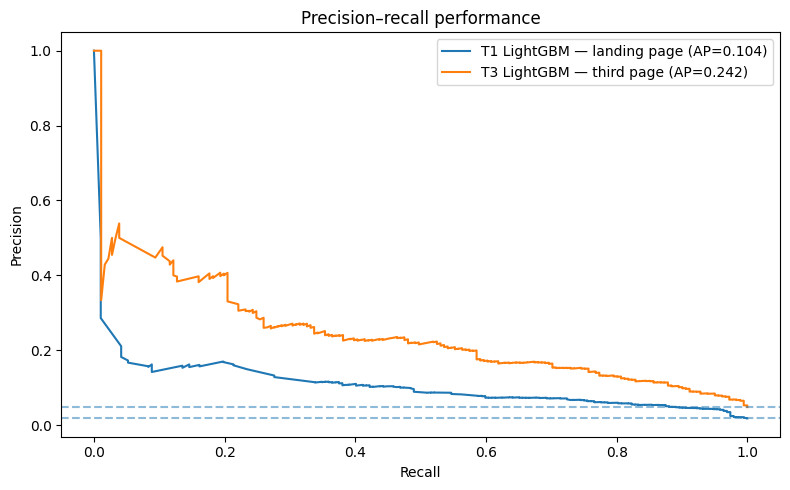

In [14]:
# Precision–recall curves.
fig, ax = plt.subplots(figsize=(8, 5))
for result in [T1_result, T3_result]:
    precision, recall, _ = precision_recall_curve(
        result["y_test"], result["test_probability"]
    )
    ax.plot(recall, precision, label=f"{result['label']} (AP={result['metrics']['PR_AUC']:.3f})")
    ax.axhline(
        result["metrics"]["test_conversion_rate"],
        linestyle="--",
        alpha=0.5,
    )

ax.set_title("Precision–recall performance")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend()
plt.tight_layout()
plt.show()


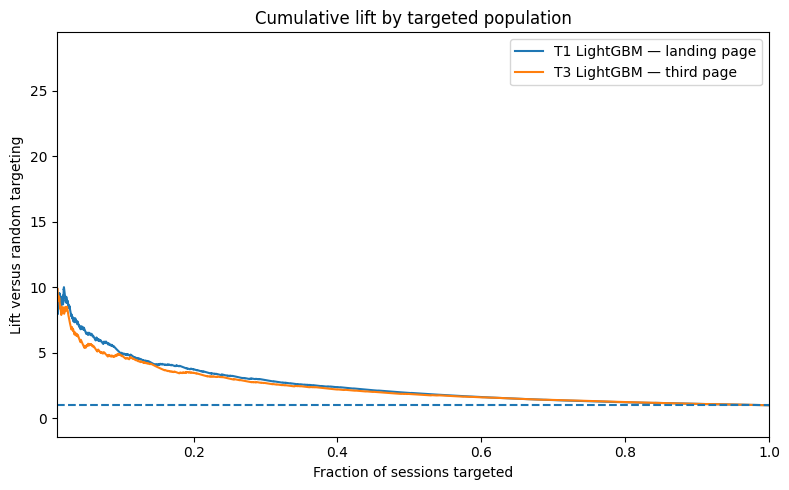

In [15]:
def cumulative_lift_curve(y_true, probabilities):
    y = np.asarray(y_true)
    order = np.argsort(probabilities)[::-1]
    ranked = y[order]
    cumulative_fraction = np.arange(1, len(y) + 1) / len(y)
    cumulative_gain = np.cumsum(ranked) / ranked.sum()
    lift = cumulative_gain / cumulative_fraction
    return cumulative_fraction, lift

fig, ax = plt.subplots(figsize=(8, 5))
for result in [T1_result, T3_result]:
    fraction, lift = cumulative_lift_curve(
        result["y_test"], result["test_probability"]
    )
    ax.plot(fraction, lift, label=result["label"])

ax.axhline(1, linestyle="--")
ax.set_xlim(0.01, 1)
ax.set_title("Cumulative lift by targeted population")
ax.set_xlabel("Fraction of sessions targeted")
ax.set_ylabel("Lift versus random targeting")
ax.legend()
plt.tight_layout()
plt.show()


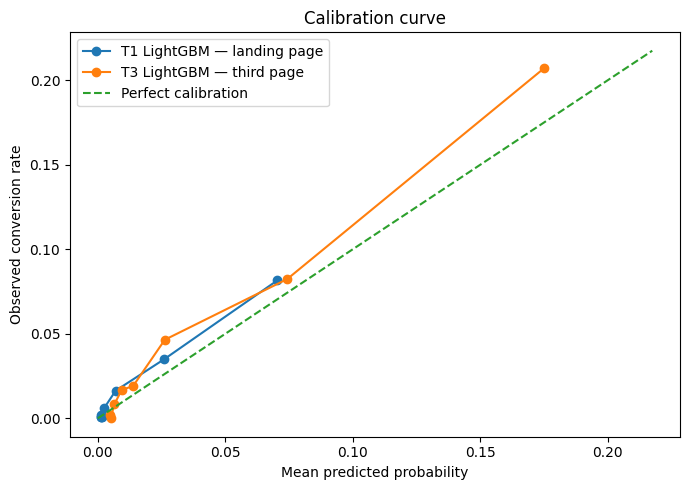

In [16]:
# Probability calibration after Platt scaling.
fig, ax = plt.subplots(figsize=(7, 5))
for result in [T1_result, T3_result]:
    observed, predicted = calibration_curve(
        result["y_test"],
        result["test_probability"],
        n_bins=8,
        strategy="quantile",
    )
    ax.plot(predicted, observed, marker="o", label=result["label"])

max_value = max(ax.get_xlim()[1], ax.get_ylim()[1])
ax.plot([0, max_value], [0, max_value], linestyle="--", label="Perfect calibration")
ax.set_title("Calibration curve")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed conversion rate")
ax.legend()
plt.tight_layout()
plt.show()


## 8. Model interpretation

Feature contributions are calculated directly from the LightGBM trees. Global importance answers **which variables drive predictions overall**; a local explanation shows **why a specific session received a high score**. These explanations describe the model, not causal effects.


**Global contribution importance — T1 LightGBM — landing page**

,mean_absolute_contribution
country,0.6929
landingPage,0.2235
device,0.2113
newVisitor,0.1562
region,0.0840
source,0.0672
browser,0.0555
sessionNumber,0.0460
medium,0.0266
hour_sin,0.0170


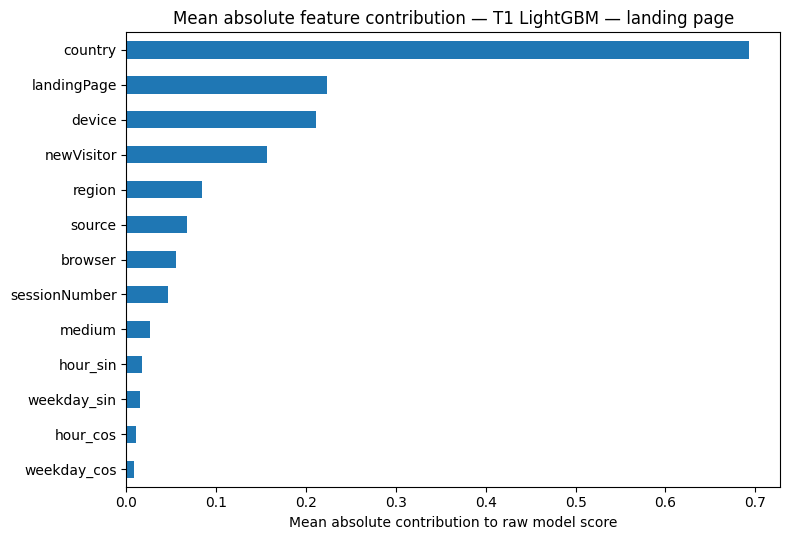

**Global contribution importance — T3 LightGBM — third page**

,mean_absolute_contribution
country,0.4996
thirdPage,0.3198
secondPage,0.1574
newVisitor,0.1484
landingPage,0.0532
device,0.0532
sessionNumber,0.0494
region,0.0437
medium,0.0359
weekday_cos,0.0247


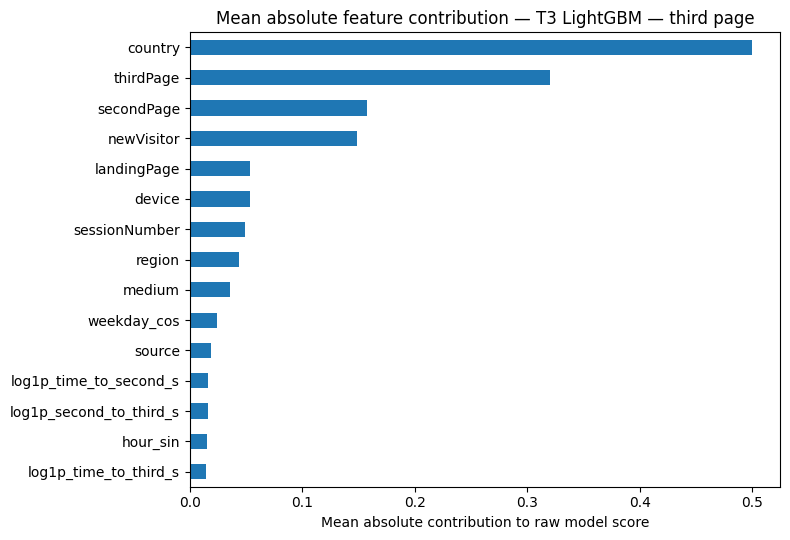

In [17]:
def mean_absolute_contributions(result, sample_size=3_000):
    X = result["X_test"]
    sample = X.sample(min(sample_size, len(X)), random_state=RANDOM_STATE)
    contributions = result["model"].booster_.predict(sample, pred_contrib=True)
    importance = pd.Series(
        np.abs(contributions[:, :-1]).mean(axis=0),
        index=result["features"],
        name="mean_absolute_contribution",
    ).sort_values(ascending=False)
    return importance

for result in [T1_result, T3_result]:
    importance = mean_absolute_contributions(result)
    display(Markdown(f"**Global contribution importance — {result['label']}**"))
    display(importance.head(15).to_frame())

    fig, ax = plt.subplots(figsize=(8, 5.5))
    importance.head(15).sort_values().plot(kind="barh", ax=ax)
    ax.set_title(f"Mean absolute feature contribution — {result['label']}")
    ax.set_xlabel("Mean absolute contribution to raw model score")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()


Checkpoint: T1 LightGBM — landing page
Calibrated probability: 10.14%
Observed outcome: 0


,feature,value,contribution
10,country,United States,1.1946
12,landingPage,/basket.html,0.4762
8,device,desktop,0.3409
0,newVisitor,0,0.2963
7,source,(direct),0.1125
1,sessionNumber,3,0.0966
11,region,not available in demo dataset,0.0413
9,browser,Chrome,0.0365
6,medium,(none),0.0284
2,hour_sin,-0.2588190451025208,0.0127


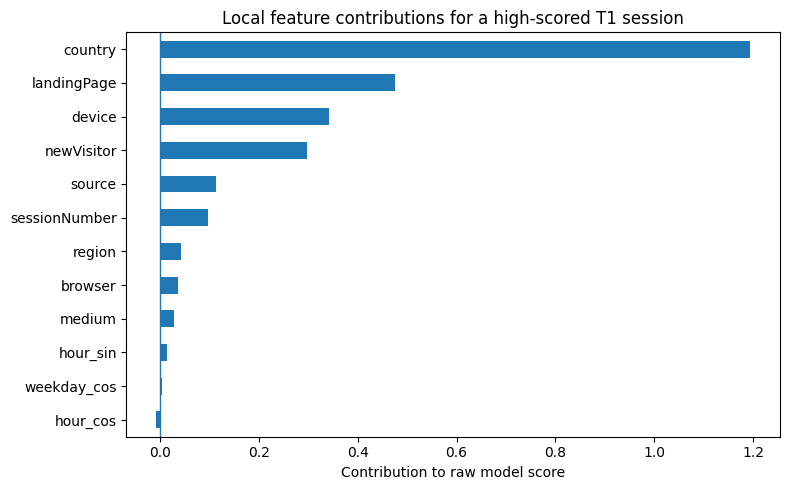

In [18]:
def local_explanation(result, row_position=None, top_n=12):
    probabilities = result["test_probability"]
    if row_position is None:
        row_position = int(np.argmax(probabilities))

    X_row = result["X_test"].iloc[[row_position]]
    contributions = result["model"].booster_.predict(X_row, pred_contrib=True)[0][:-1]

    explanation = pd.DataFrame(
        {
            "feature": result["features"],
            "value": [str(X_row.iloc[0][feature]) for feature in result["features"]],
            "contribution": contributions,
        }
    )
    explanation["absolute_contribution"] = explanation["contribution"].abs()
    explanation = explanation.sort_values("absolute_contribution", ascending=False).head(top_n)

    print(f"Checkpoint: {result['label']}")
    print(f"Calibrated probability: {probabilities[row_position]:.2%}")
    print(f"Observed outcome: {int(result['y_test'].iloc[row_position])}")
    display(explanation[["feature", "value", "contribution"]])

    fig, ax = plt.subplots(figsize=(8, 5))
    explanation.sort_values("contribution").set_index("feature")["contribution"].plot(
        kind="barh", ax=ax
    )
    ax.axvline(0, linewidth=1)
    ax.set_title("Local feature contributions for a high-scored T1 session")
    ax.set_xlabel("Contribution to raw model score")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()

local_explanation(T1_result)


## 9. Activation on Google technology

### Proposed architecture

```text
Web/app events
    ↓
Google tag / server-side tagging
    ↓
Feature service or streaming transformation
    ↓
Online model endpoint
    ↓
Latest propensity score
    ├── On-site experience / CMS
    ├── Analytics and experimentation
    └── Audience activation for future sessions
```

A practical batch and monitoring path can also export analytics data to BigQuery, train or refresh the model on historical data, and serve online predictions through a managed endpoint. The exact implementation should be chosen with the client's latency, consent, volume and cost requirements.

### Use case 1 — on-site personalisation

Refresh the score after each observed checkpoint:

- **High propensity:** reduce checkout friction, emphasise delivery/payment information, or preserve the current path without unnecessary interruption.
- **Medium propensity:** show relevant product recommendations, reviews or reassurance.
- **Low propensity:** prioritise discovery, search support or category navigation.

### Use case 2 — audience activation

Create governed propensity bands for eligible, consented users:

- Prioritise high-propensity non-buyers for remarketing.
- Suppress recent purchasers where appropriate.
- Adjust frequency, creative or bidding strategy based on expected value and campaign objective.

Advertising activation may be near-real-time or targeted at future sessions rather than truly instantaneous because audience-processing latency can apply.

### Use case 3 — experimentation and incremental value

Propensity is not uplift. A visitor with a high probability may purchase without any incentive. Automatically discounting high-propensity users can therefore destroy margin.

Recommended sequence:

1. Rank sessions with the propensity model.
2. Randomise interventions within propensity bands.
3. Measure incremental conversion, revenue and margin.
4. Progress to uplift modelling when treatment data is sufficient.

### Official platform references

- [Google Analytics — BigQuery Export](https://support.web-platform.example/analytics/answer/9358801?hl=en)
- [Vertex AI — online predictions for custom-trained models](https://docs.cloud.web-platform.example/vertex-ai/docs/predictions/get-online-predictions)
- [Google Tag Manager — server-side tagging](https://developers.web-platform.example/tag-platform/tag-manager/server-side)
- [Display & Video 360 — audience list targeting](https://support.web-platform.example/displayvideo/answer/2949947?hl=en)


## 10. Production design and monitoring

### Serving

- Package feature transformations and model artefacts together.
- Enforce checkpoint-specific schemas so future-page fields cannot enter an earlier model.
- Return a calibrated probability, model version and scoring timestamp.
- Define latency and fail-safe behaviour; the website should continue normally if scoring is unavailable.

### Monitoring

Track at least:

- Prediction volume and latency
- Feature missingness and unseen-category rate
- Score distribution and population stability
- Calibration and PR-AUC once outcomes mature
- Top-decile lift
- Performance by device, country and traffic source
- Incremental revenue/margin from controlled experiments

### Governance and privacy

- Use consented first-party data and minimise personal identifiers.
- Apply retention, access-control and audit requirements.
- Avoid using the score for sensitive or unfair treatment.
- Document feature lineage, model versioning and intended use.


## 11. Limitations and next steps

### Current limitations

1. Only about one month of data is available.
2. No transaction timestamp is supplied, so page events cannot be definitively ordered relative to purchase.
3. Revenue, margin, product value, stock and intervention cost are absent.
4. Repeated session identifiers need source-system clarification.
5. The sample may not represent current traffic or future campaigns.
6. Observational feature importance does not establish causality.

### Recommended next steps

1. Validate session and event semantics with analytics engineers.
2. Add transaction time and construct true event-level checkpoints.
3. Backtest over multiple months with rolling windows.
4. Add value-based targets such as expected revenue or margin.
5. Run a shadow deployment to validate latency, drift and calibration.
6. Launch an A/B test using propensity bands.
7. Retrain or recalibrate according to measured drift and business seasonality.


## Conclusion

The prototype shows that intra-session conversion modelling is technically feasible, but the strongest design choice is not the algorithm: it is the **time-aware definition of the prediction problem**.

A useful solution should:

- use only information available at each checkpoint;
- rank rare conversions effectively;
- output calibrated probabilities;
- explain the factors influencing a score;
- activate scores through testable business interventions; and
- be judged by incremental revenue or margin, not only offline model metrics.

> **Final recommendation:** start with the T1 model for broad early-session scoring, refresh the probability as behaviour accumulates, and validate every intervention through controlled experimentation.
